# FORMAT-STYLE COMPARISON

## IMPORTS

In [202]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

The goal here is to compare the following attributes for both channels :

• video duration / title length / description length


• focus on title : punctuation (question / exclamation marks) + calls to action (lien en description)


• calls to action (lien en description)

While taking into account the evolution of these features accross time.

# DEFINITION OF CONSTANTS

In [203]:
COLOR_INST = "#FC8D62"
COLOR_IND = "#66C2A5"

# True : Institutional channels / False : Independent channels
COLOR_MAP = {True: COLOR_INST, False: COLOR_IND}

SHADES_INST = {"EPFL" : "#F3CEBF", "ETH Zürich" : "#E98D69", "MIT" : "#E96E3D", "Stanford" : "#C73800"}
SHADES_IND = {"3Blue1Brown" : "#A2C9BD", "Kurzgesagt – In a Nutshell" : "#5CB99C", "Lectures by Walter Lewin" : "#2FA781", "minutephysics" : "#007E56"}

SHADES_MAP = {**SHADES_INST, **SHADES_IND}

## LOAD AND PREPROCESS DATAFRAME

In [204]:
data = pd.read_csv("../../data/processed/videos_cleaned.csv")
channel_data = pd.read_csv("../../data/processed/channels.csv")

In [205]:
data["channel_title"] = data["channel_title"].replace("Massachusetts Institute of Technology (MIT)", "MIT")
data["channel_title"] = data["channel_title"].replace("Lectures by Walter Lewin. They will make you ♥ Physics.", "Lectures by Walter Lewin")

In [206]:
# creation of columns specific to my analysis
data["duration_mn"] = data["duration_seconds"] / 60
data["title_len_words"] = data["title"].str.split().str.len()
data["description_len_words"] = data["description"].str.split().str.len()

Let's do a basic analysis and check the evolution of the number of videos published per year by each channel.

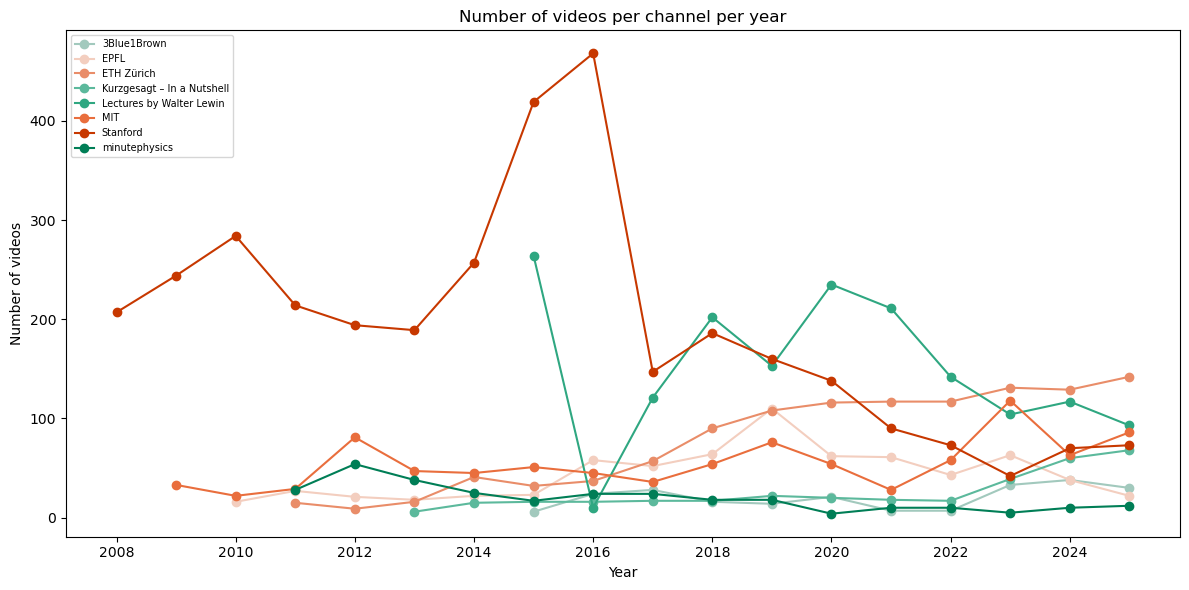

In [207]:
video_counts = (data.groupby(["published_year", "channel_title"])["title"].count().reset_index().rename(columns={"title": "video_count"}))

fig, ax = plt.subplots(figsize=(12, 6))
for channel, channel_df in video_counts.groupby("channel_title"):
    ax.plot(channel_df["published_year"], channel_df["video_count"], marker="o", label=channel, color=SHADES_MAP[channel])

ax.set_title("Number of videos per channel per year")
ax.set_xlabel("Year")
ax.set_ylabel("Number of videos")
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.legend(fontsize=7, loc="upper left")

plt.tight_layout()
plt.savefig("visualizations/nb_videos_per_channel_per_year.png")
plt.show()

## A. Video / Title / Description Length

Let's see what we are dealing with :)

In [208]:
print(data.groupby("Institution")[["duration_mn", "title_len_words", "description_len_words"]].describe().round(1).to_string())

            duration_mn                                         title_len_words                                     description_len_words                                            
                  count  mean   std  min  25%  50%   75%    max           count mean  std  min  25%  50%  75%   max                 count  mean    std  min   25%   50%    75%    max
Institution                                                                                                                                                                          
False            2503.0   9.2  14.2  0.0  2.1  4.4   9.7  116.0          2504.0  7.1  3.0  1.0  5.0  7.0  9.0  21.0                2398.0  81.2  130.0  1.0   6.0   9.0  114.8  632.0
True             6232.0  21.2  34.2  0.0  2.0  3.4  31.3  569.0          6238.0  7.0  3.0  1.0  5.0  7.0  9.0  20.0                6079.0  73.5   55.2  0.0  38.0  59.0   91.0  677.0


In [209]:
# definition of metrics that will be analyzed in between and within groups
format_metrics = [("duration_mn", "Video Duration (min)"), ("title_len_words", "Title Length (words)"),("description_len_words", "Description Length (words)")]

Let's plot the metrics to perform between groups comparison.

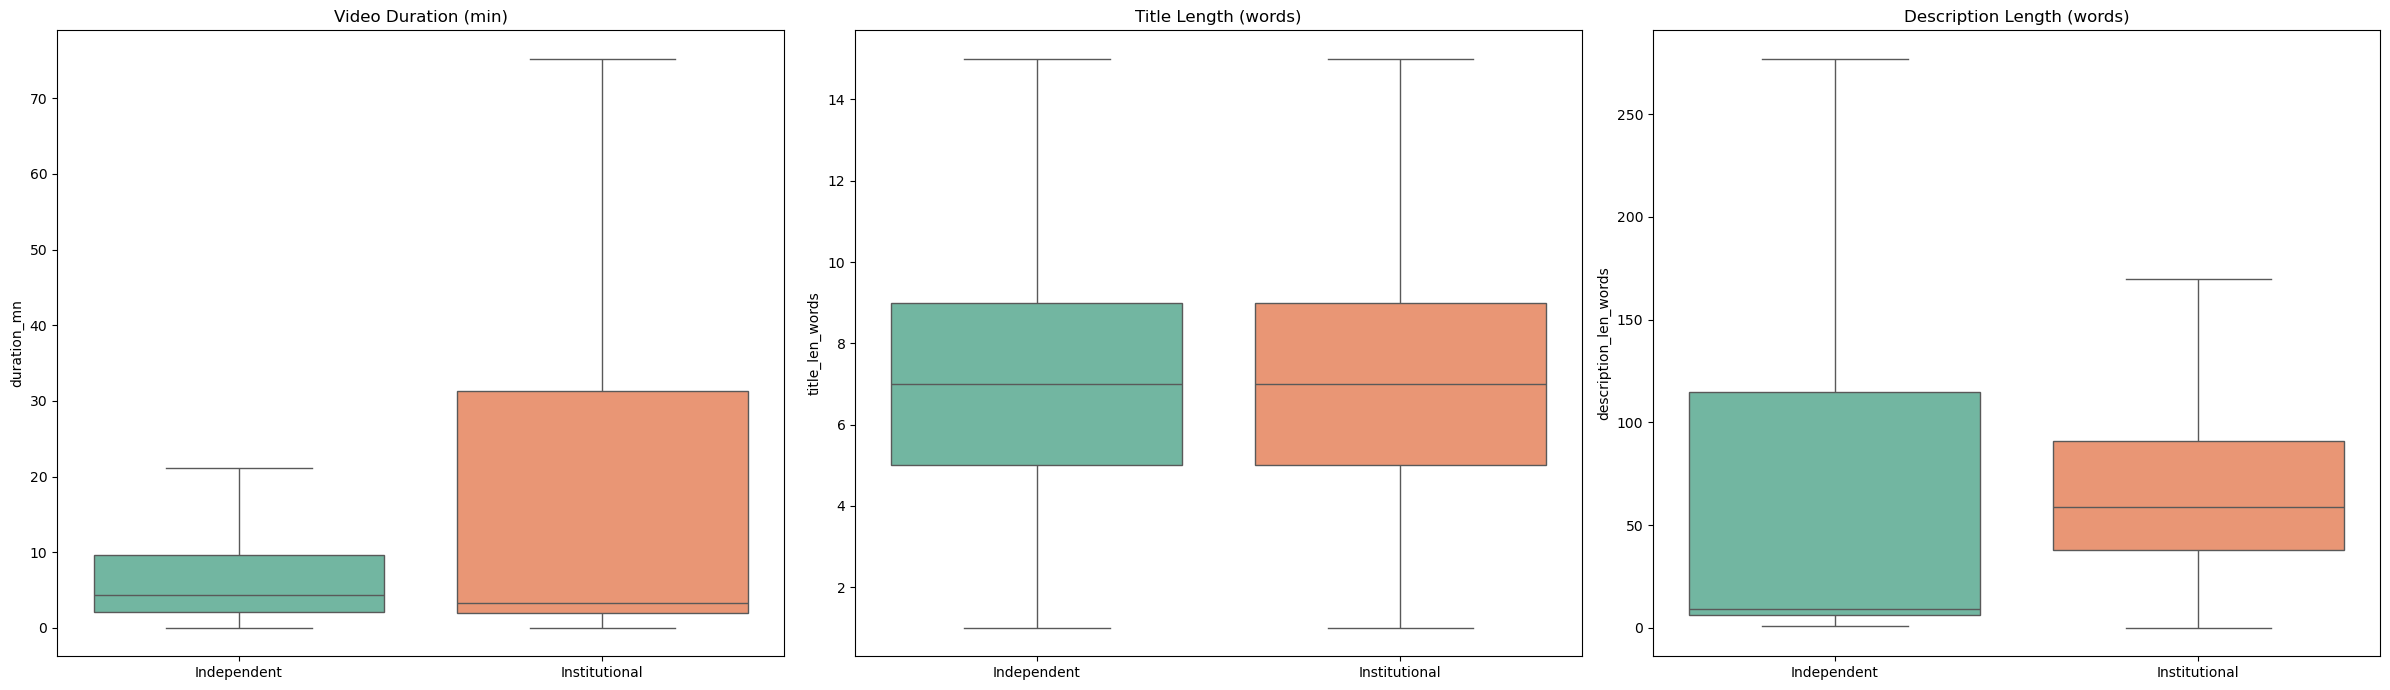

In [210]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

for ax, (col, label) in zip(axes, format_metrics):
    sns.boxplot(data=data, x="Institution", y=col, ax=ax,
                hue="Institution", palette=COLOR_MAP, legend=False, showfliers=False)
    ax.set_title(label)
    ax.set_xlabel("")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Independent", "Institutional"])
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig("visualizations/boxplot_format_metrics.png")
plt.show()

Let's analyze within each group, starting with the institutional one.

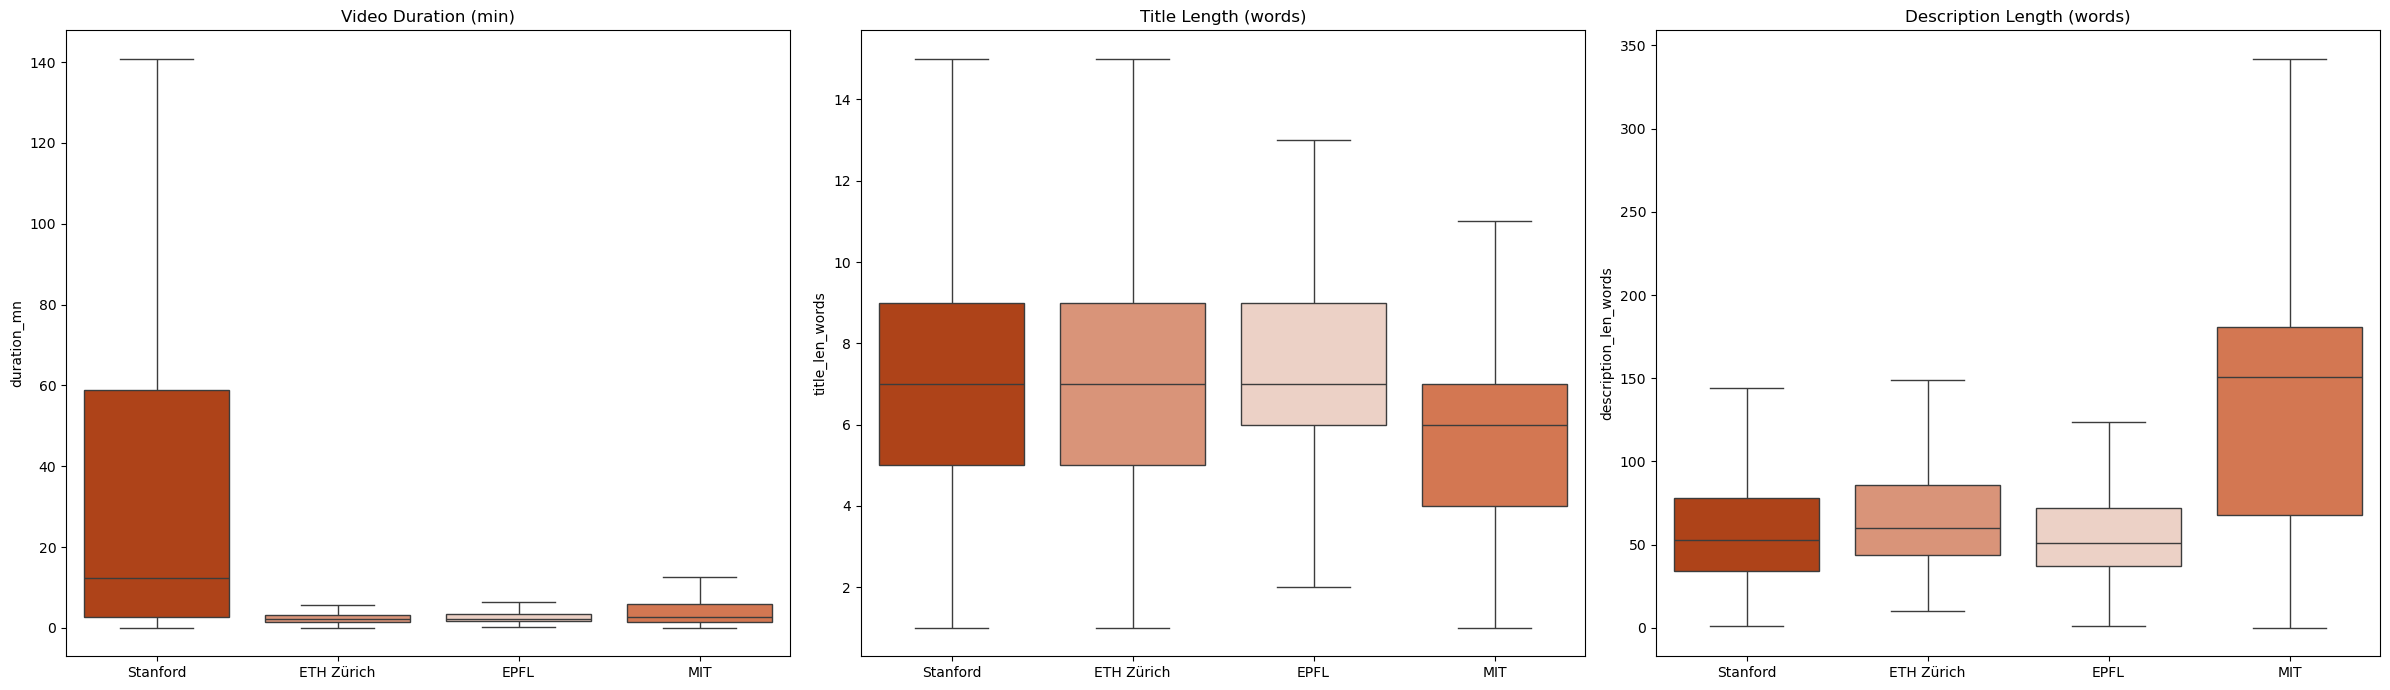

In [211]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

for ax, (col, label) in zip(axes, format_metrics):
    sns.boxplot(data=data[data["Institution"] == True], x="channel_title", y=col, ax=ax,
            hue="channel_title", palette=SHADES_INST, legend=False, showfliers=False)
    ax.set_title(label)
    ax.set_xlabel("" if True else "")
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig("visualizations/boxplot_format_metrics_instit.png")
plt.show()

Let's continue with the second group.

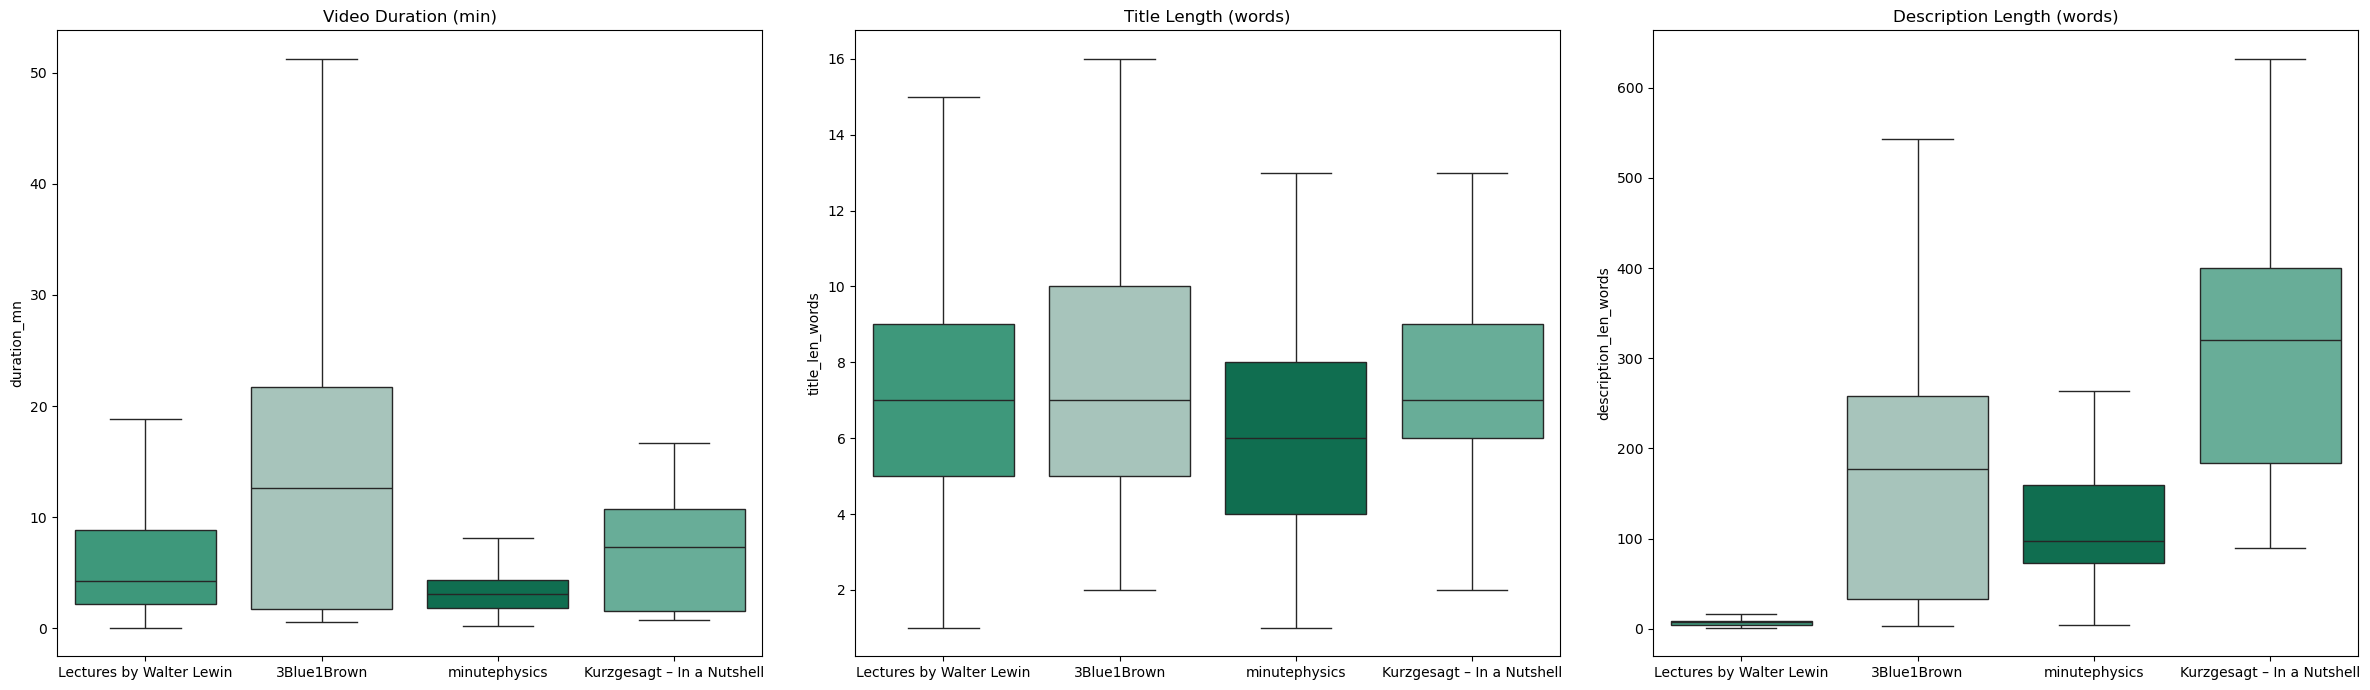

In [212]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

for ax, (col, label) in zip(axes, format_metrics):
    sns.boxplot(data=data[data["Institution"] == False], x="channel_title", y=col, ax=ax,
            hue="channel_title", palette=SHADES_IND, legend=False, showfliers=False)
    ax.set_title(label)
    ax.set_xlabel("" if True else "")
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig("visualizations/boxplot_format_metrics_indep.png")
plt.show()

### Evolution throughout the years

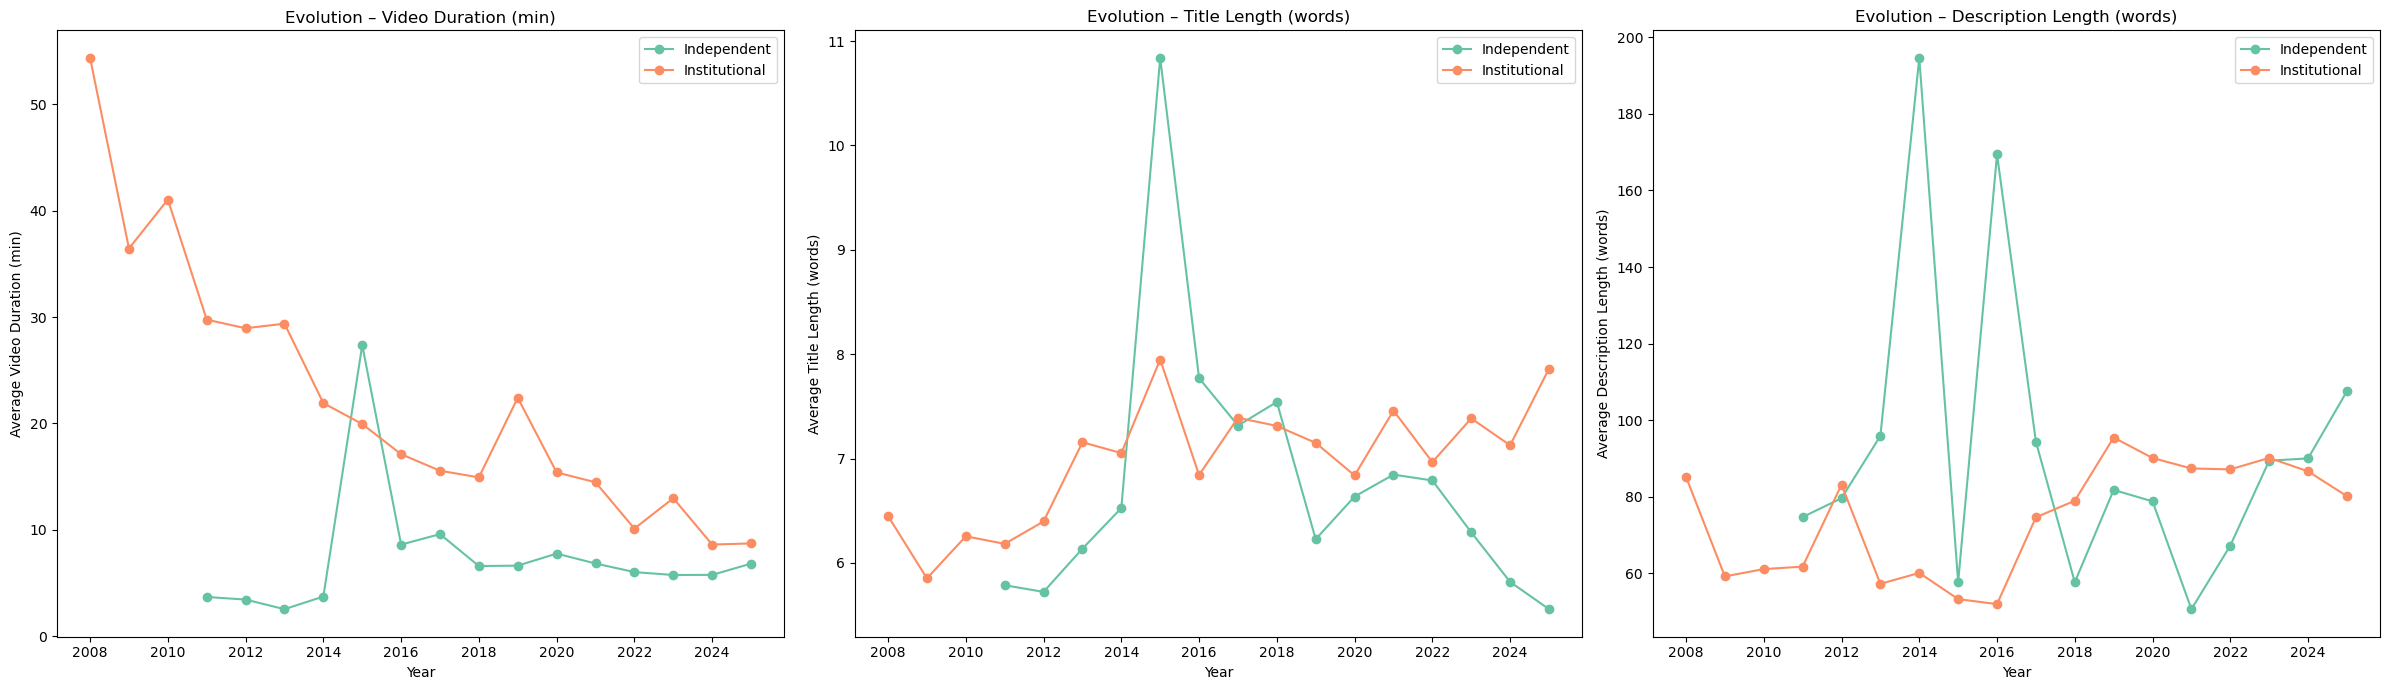

In [213]:
evo_metrics = (data.groupby(["published_year", "Institution"])[["duration_mn", "title_len_words", "description_len_words"]].mean().reset_index())

fig, axes = plt.subplots(1, 3, figsize=(24, 7))
for ax, (col, label) in zip(axes, format_metrics):
    for inst, inst_df in evo_metrics.groupby("Institution"):
        label_name = "Institutional" if inst else "Independent"
        ax.plot(inst_df["published_year"], inst_df[col], marker="o", label=label_name, color=COLOR_MAP[inst])
    ax.set_title(f"Evolution – {label}")
    ax.set_xlabel("Year")
    ax.set_ylabel("Average " + label)
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.legend()

plt.tight_layout()
plt.savefig("visualizations/evo_format_metrics.png")
plt.show()

### Consistency in each group

### (1) Institutional channels

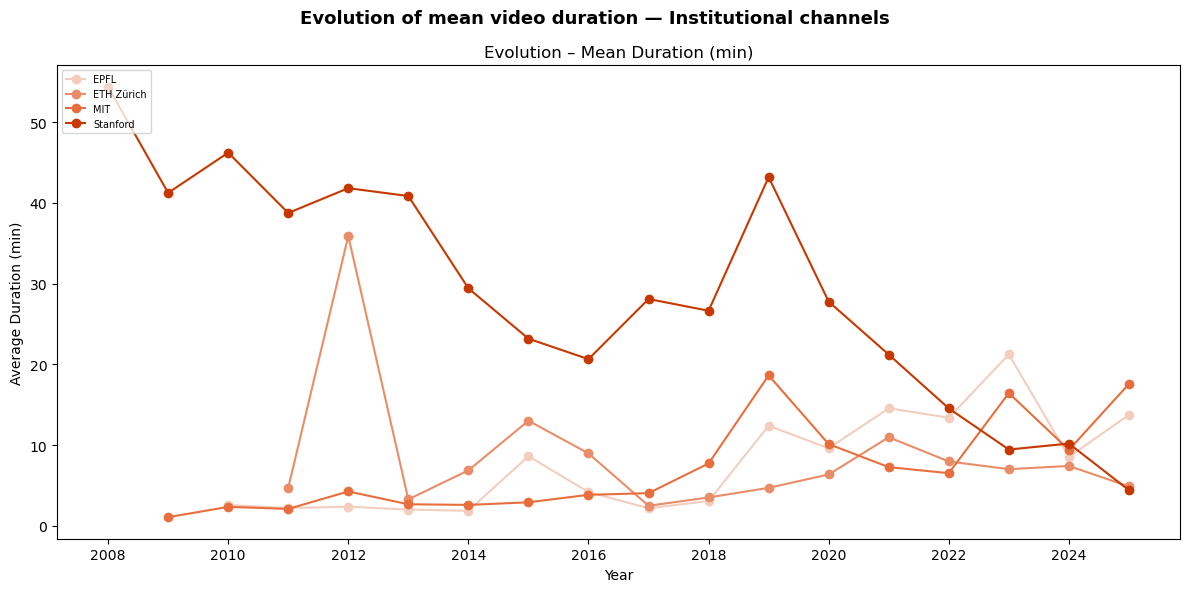

In [214]:
data["published_at"] = pd.to_datetime(data["published_at"], utc=True, errors="coerce")
data["published_year"] = data["published_at"].dt.year

institutional_data = data[data["Institution"] == True]

evo_metrics = (institutional_data.groupby(["published_year", "channel_title"])["duration_mn"].mean().reset_index())

fig, ax = plt.subplots(figsize=(12, 6))
for channel, channel_df in evo_metrics.groupby("channel_title"):
    ax.plot(channel_df["published_year"], channel_df["duration_mn"], marker="o", label=channel, color=SHADES_INST[channel])

ax.set_title("Evolution – Mean Duration (min)")
ax.set_xlabel("Year")
ax.set_ylabel("Average Duration (min)")
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.legend(fontsize=7, loc="upper left")

plt.suptitle("Evolution of mean video duration — Institutional channels", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("visualizations/evo_mean_duration_instit.png")
plt.show()

### (2) Independent channels

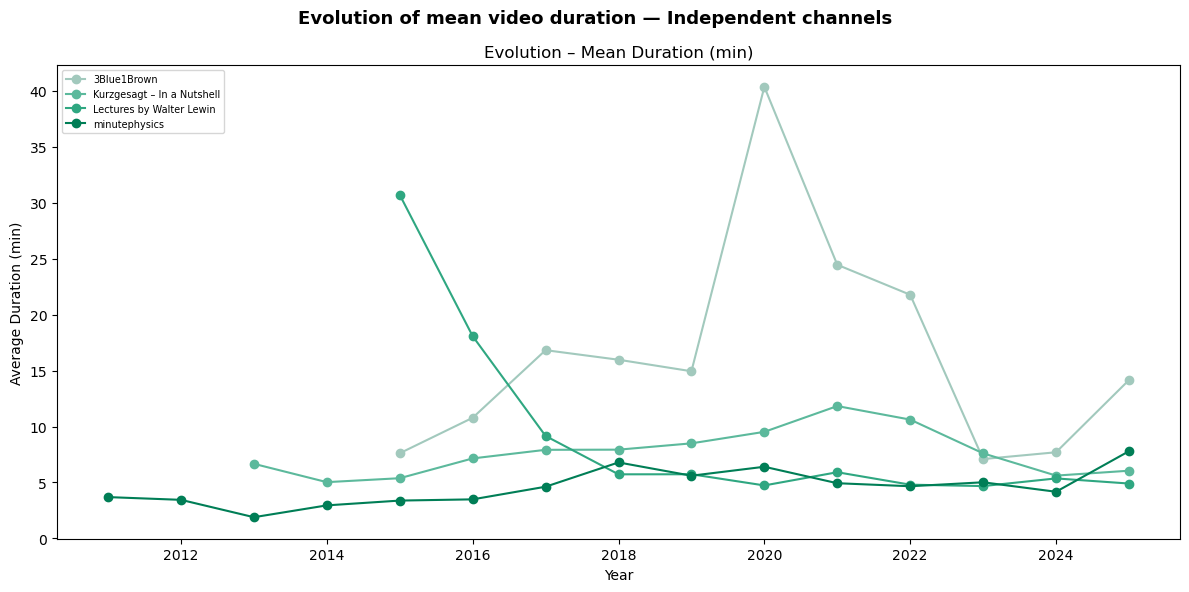

In [215]:
data["published_at"] = pd.to_datetime(data["published_at"], utc=True, errors="coerce")
data["published_year"] = data["published_at"].dt.year

independent_data = data[data["Institution"] == False]

evo_metrics = (independent_data.groupby(["published_year", "channel_title"])["duration_mn"].mean().reset_index())

fig, ax = plt.subplots(figsize=(12, 6))
for channel, channel_df in evo_metrics.groupby("channel_title"):
    ax.plot(channel_df["published_year"], channel_df["duration_mn"], marker="o", label=channel, color=SHADES_IND[channel])

ax.set_title("Evolution – Mean Duration (min)")
ax.set_xlabel("Year")
ax.set_ylabel("Average Duration (min)")
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.legend(fontsize=7, loc="upper left")

plt.suptitle("Evolution of mean video duration — Independent channels", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("visualizations/evo_mean_duration_indep.png")
plt.show()

## B. Focus on title

Definition of a function that will only be used in this section.

In [216]:
sia = SentimentIntensityAnalyzer()

def extract_title_features(title: str) -> dict:
    """
    Extracts targetted features from a video title.

    Args:
        title (str): title of a video

    Returns:
        dict: dictionary containing the extracted features.
    """
    ttl = str(title)
    lower_ttl = ttl.lower().strip()

    return {
        "has_question_mark": int('?' in ttl),
        "has_exclamation_mark": int('!' in ttl),
        "has_figure": int(bool(re.search(r'\d', ttl))),
        "starts_with_how": int(lower_ttl.startswith('how')),
        'starts_with_why': int(lower_ttl.startswith('why')),
        'starts_with_what': int(lower_ttl.startswith('what')), 
    }

In [217]:
features = data['title'].apply(extract_title_features).apply(pd.Series)
concat_data = pd.concat([data, features], axis=1)

In [218]:
# key value of the dictionnary formerly established
features = ["has_question_mark","has_exclamation_mark", "has_figure", "starts_with_how","starts_with_why","starts_with_what"]

# calculating the distribution of each within for each group
distrib_features = (concat_data.groupby("Institution")[features].mean().mul(100).rename(index={True:"Institutional", False:"Independent"}).T)
distrib_features.columns.name = None

### Plotting the distribution of formats

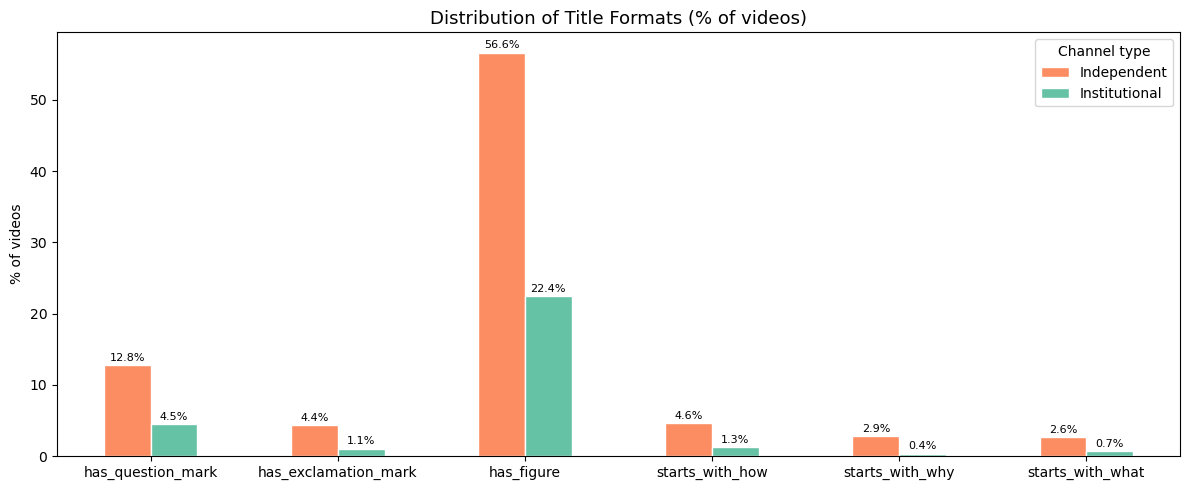

In [219]:
ax = distrib_features.plot(kind="bar", figsize=(12, 5), color=[COLOR_INST, COLOR_IND], edgecolor="white")
ax.set_title("Distribution of Title Formats (% of videos)", fontsize=13)
ax.set_ylabel("% of videos")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title="Channel type")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width()/2, p.get_height() + 0.3), ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.savefig("visualizations/distrib_title_formats.png")
plt.show()

### Plotting the evolution of punctuation marks for each group

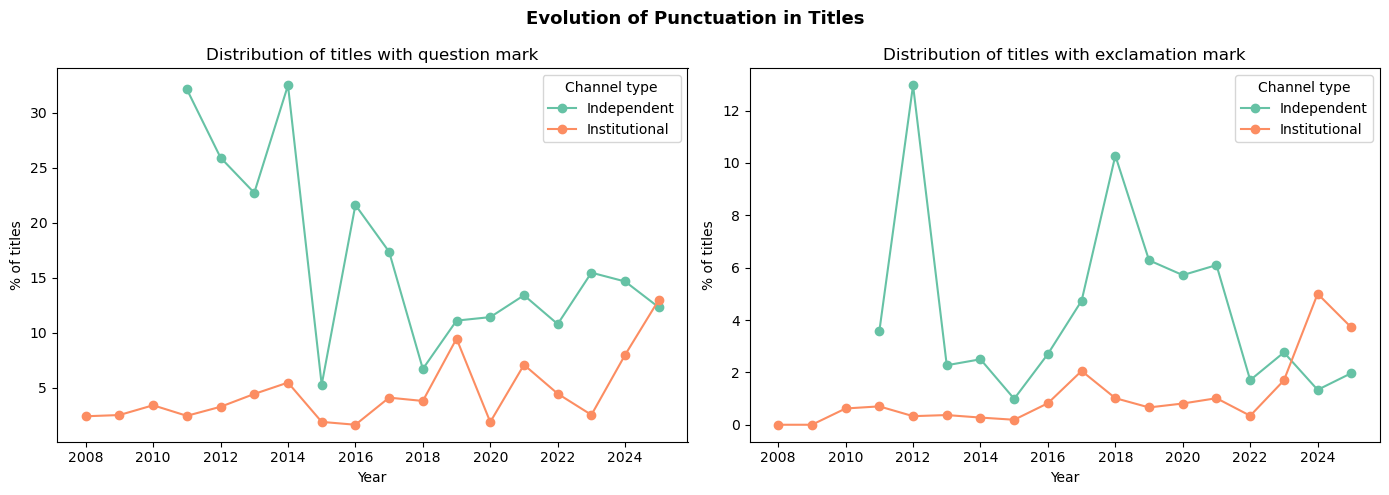

In [220]:
evo_punct = (concat_data.groupby(["published_year","Institution"])[["has_question_mark","has_exclamation_mark"]].mean().mul(100).reset_index())
evo_punct["group"] = evo_punct["Institution"].map({True:"Institutional", False:"Independent"})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, label in zip(axes, ["has_question_mark","has_exclamation_mark"],
                           ["Distribution of titles with question mark","Distribution of titles with exclamation mark"]):
    for grp, gdf in evo_punct.groupby("group"):
        ax.plot(gdf["published_year"], gdf[col], marker="o", label=grp, color=COLOR_MAP[gdf["Institution"].iloc[0]])
    ax.set_title(f"{label}")
    ax.set_xlabel("Year"); ax.set_ylabel("% of titles")
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.legend(title="Channel type")
plt.suptitle("Evolution of Punctuation in Titles", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("visualizations/distrib_punct_titles.png")
plt.show()

## C. Call to action

There are different ways to check the Call To Actions :
- does the video description contains link.s ?
    - if so, how many ?
- does the description include keywords linked to Call To Action (CTA) ?

In [221]:
# definition of constants: the typical URL format and a bank of words commonly used for CTA
URL_FORMAT = re.compile(r'https?://\S+|www\.\S+', re.IGNORECASE)
CTA_BANK_WORDS = r'subscribe|follow|like|comment|share|click|check|link|watch|join'

In [222]:
concat_data["nb_links"] = concat_data["description"].apply(lambda x: 0 if pd.isna(x) else len(URL_FORMAT.findall(str(x))))
concat_data["has_link"] = (concat_data["nb_links"] > 0).astype("int64")

concat_data["nb_cta"] = concat_data["description"].apply(lambda x: 0 if pd.isna(x) else int(bool(re.search(CTA_BANK_WORDS, str(x).lower()))))
concat_data["has_cta"] = (concat_data["nb_cta"] > 0).astype("int64")

print(concat_data.groupby("Institution")[["has_link", "nb_links", "has_cta", "nb_cta"]].mean().mul(100).round(1))

             has_link  nb_links  has_cta  nb_cta
Institution                                     
False            38.1     520.0     30.6    30.6
True             66.4     200.8     33.6    33.6


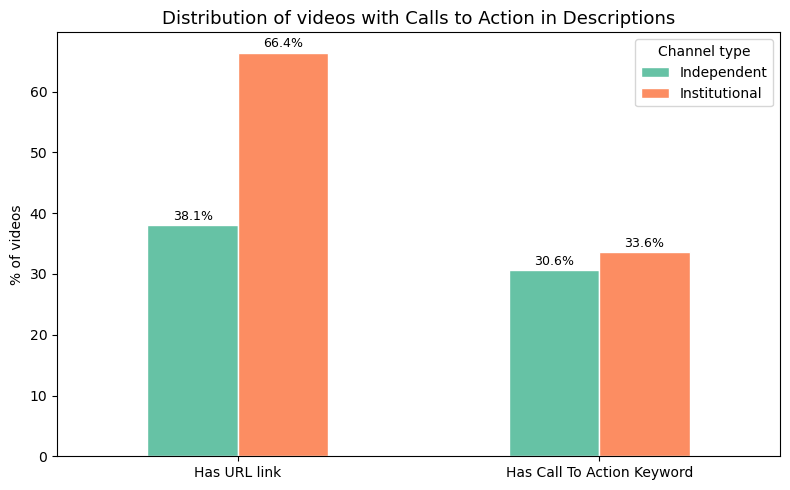

In [223]:
# calculate the group distribution of videos including link.s or one of the defined CTA keyword
distrib_cta = (concat_data.groupby("Institution")[["has_link","has_cta"]].mean().mul(100).rename(index={True:"Institutional", False:"Independent"}, columns={"has_link":"Has URL link","has_cta":"Has Call To Action Keyword"}).T)

ax = distrib_cta.plot(kind="bar", figsize=(8, 5), color={"Institutional": COLOR_INST, "Independent": COLOR_IND}, edgecolor="white")
ax.set_title("Distribution of videos with Calls to Action in Descriptions", fontsize=13)
ax.set_ylabel("% of videos")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width()/2, p.get_height() + 0.4), ha="center", va="bottom", fontsize=9)
ax.legend(title="Channel type")
plt.tight_layout()
plt.savefig("visualizations/distrib_presence_cta_url.png")
plt.show()

### Plot the evolution of the use of CTA for each group

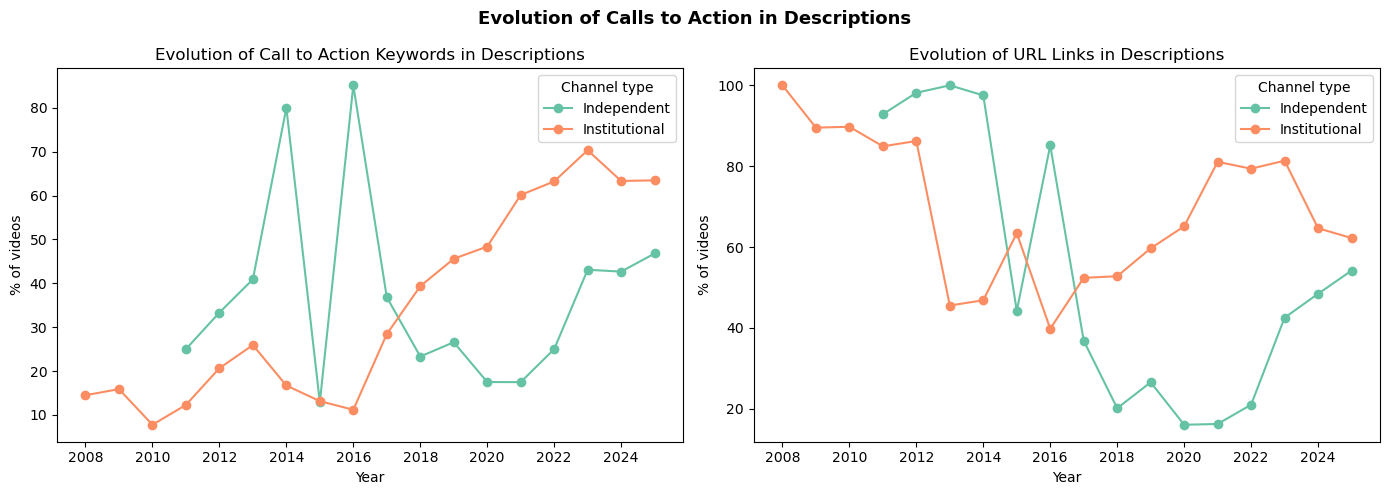

In [224]:
evo_cta = (concat_data.groupby(["published_year", "Institution"])[["has_link", "has_cta"]].mean().mul(100).reset_index())
evo_cta["group"] = evo_cta["Institution"].map({True: "Institutional", False: "Independent"})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, label in zip(axes, ["has_cta", "has_link"], ["Call to Action Keywords", "URL Links"]):
    for grp, gdf in evo_cta.groupby("group"):
        ax.plot(gdf["published_year"], gdf[col], marker="o", label=grp, color=COLOR_MAP[gdf["Institution"].iloc[0]])
    ax.set_title(f"Evolution of {label} in Descriptions")
    ax.set_xlabel("Year")
    ax.set_ylabel("% of videos")
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.legend(title="Channel type")

plt.suptitle("Evolution of Calls to Action in Descriptions", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("visualizations/evo_cta_url.png")
plt.show()

### Consistency within each group

### (1) Institutionnal Channels

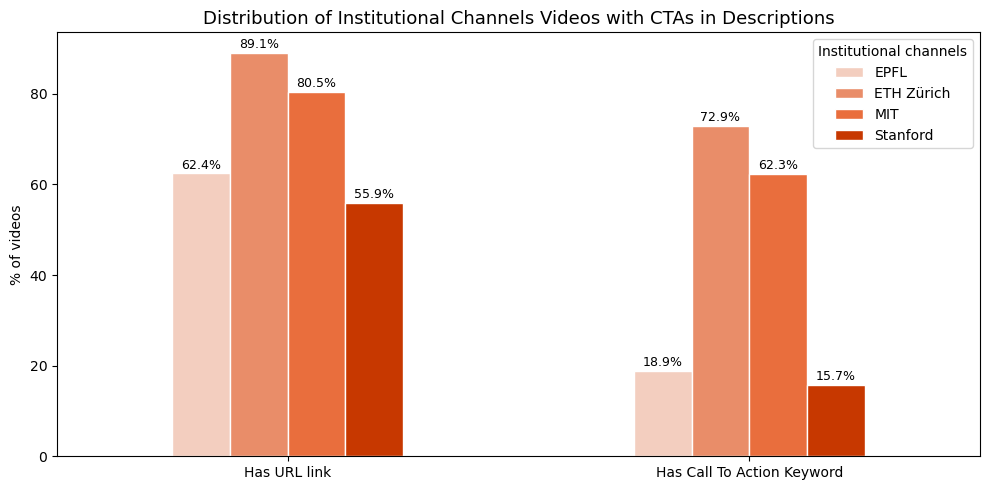

In [225]:
distrib_cta_instit = (concat_data[concat_data["Institution"] == True].groupby("channel_title")[["has_link", "has_cta"]].mean().mul(100)
    .rename(columns={"has_link": "Has URL link", "has_cta": "Has Call To Action Keyword"}).T)

ax = distrib_cta_instit.plot(kind="bar", figsize=(10, 5), color=[SHADES_INST[ch] for ch in distrib_cta_instit.columns], edgecolor="white")
ax.set_title("Distribution of Institutional Channels Videos with CTAs in Descriptions", fontsize=13)
ax.set_ylabel("% of videos")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width()/2, p.get_height() + 0.4), ha="center", va="bottom", fontsize=9)

ax.legend(title="Institutional channels")
plt.tight_layout()
plt.savefig("visualizations/distrib_url_cta_instit.png")
plt.show()

### (2) Independent channels

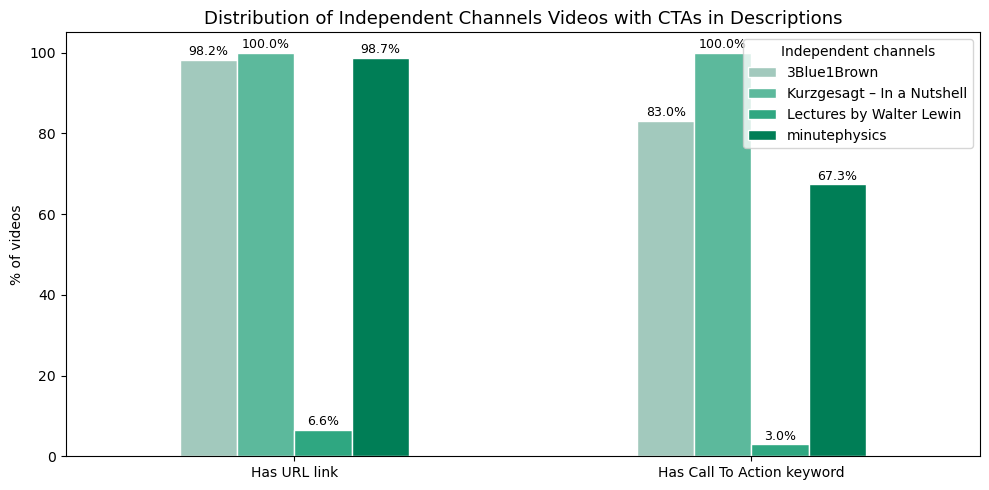

In [226]:
distrib_cta_indep = (concat_data[concat_data["Institution"] == False].groupby("channel_title")[["has_link", "has_cta"]].mean().mul(100)
    .rename(columns={"has_link": "Has URL link", "has_cta": "Has Call To Action keyword"}).T)

ax = distrib_cta_indep.plot(kind="bar", figsize=(10, 5), color=[SHADES_IND[ch] for ch in distrib_cta_indep.columns], edgecolor="white")

ax.set_title("Distribution of Independent Channels Videos with CTAs in Descriptions", fontsize=13)
ax.set_ylabel("% of videos")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width()/2, p.get_height() + 0.4), ha="center", va="bottom", fontsize=9)

ax.legend(title="Independent channels")
plt.tight_layout()
plt.savefig("visualizations/distrib_url_cta_indep.png")
plt.show()